# Exploratory data anylisis

Following Geeks for Geeks EDA in Python tutorial: https://www.geeksforgeeks.org/data-analysis/exploratory-data-analysis-in-python/

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

## 1.0 Load and inspect data

### 1.1 Reading my GoodReads personal data

In [2]:
df = pd.read_csv("/home/claraoberle/personal-book-recommender/data/raw/goodreads_library_export.csv")

df.head()

,Book Id,Title,Author,Author l-f,Additional Authors,ISBN,ISBN13,My Rating,Publisher,Binding,...,Date Read,Date Added,Bookshelves,Bookshelves with positions,Exclusive Shelf,My Review,Spoiler,Private Notes,Read Count,Owned Copies
0,222947,La comunidad del anillo (El señor de los anill...,J.R.R. Tolkien,"Tolkien, J.R.R.",Luis Domènech,"=""8445071408""","=""9788445071403""",0.0,Minotauro,Paperback,...,NaN,2026/07/22,currently-reading,currently-reading (#2),currently-reading,NaN,NaN,NaN,1,0
1,55659629,"It Happened One Summer (Bellinger Sisters, #1)",Tessa Bailey,"Bailey, Tessa",NaN,"=""0063045656""","=""9780063045651""",2.0,Avon,Paperback,...,2026/08/03,2026/07/30,NaN,NaN,read,Vaig començar aquest llibre perquè volia acons...,NaN,NaN,1,0
2,54438718,Una promesa de juventud,María Reig,"Reig, María",NaN,"=""8491294260""","=""9788491294269""",4.0,SUMA,Kindle Edition,...,2026/07/18,2026/07/06,NaN,NaN,read,NaN,NaN,NaN,1,0
3,22628,The Perks of Being a Wallflower,Stephen Chbosky,"Chbosky, Stephen",NaN,"=""""","=""""",5.0,MTV Books/Pocket Books,Hardcover,...,NaN,2021/08/09,NaN,NaN,read,Aquest llibre mai em defrauda. D'alguna manera...,NaN,NaN,2,0
4,36336078,"Call Me By Your Name (Call Me By Your Name, #1)",André Aciman,"Aciman, André",NaN,"=""""","=""""",3.0,Atlantic Books,Paperback,...,2026/06/30,2021/12/31,NaN,NaN,read,"<i> ""Call me by your name and I'll call you by...",NaN,NaN,1,0


### 1.2 Data description

In [3]:
df.shape

(185, 23)

There are 185 books with 23 features/dimensions.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Book Id                     185 non-null    int64  
 1   Title                       185 non-null    str    
 2   Author                      185 non-null    str    
 3   Author l-f                  185 non-null    str    
 4   Additional Authors          28 non-null     str    
 5   ISBN                        185 non-null    str    
 6   ISBN13                      185 non-null    str    
 7   My Rating                   185 non-null    float64
 8   Publisher                   183 non-null    str    
 9   Binding                     185 non-null    str    
 10  Number of Pages             183 non-null    float64
 11  Year Published              184 non-null    float64
 12  Original Publication Year   179 non-null    float64
 13  Date Read                   98 non-null     st

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Book Id,185.0,2.878202e+07,4.382892e+07,1.0,68429.00,14061957.0,42844155.0,223218970.0
My Rating,185.0,2.854054e+00,1.915412e+00,0.0,0.00,3.0,4.0,5.0
Number of Pages,183.0,4.840383e+02,3.258066e+02,0.0,325.00,391.0,552.0,3200.0
Year Published,184.0,2.010875e+03,1.196902e+01,1907.0,2004.75,2013.0,2019.0,2025.0
Original Publication Year,179.0,1.992536e+03,5.096135e+01,1590.0,1992.50,2011.0,2018.0,2025.0
Private Notes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Read Count,185.0,8.216216e-01,4.840584e-01,0.0,1.00,1.0,1.0,2.0
Owned Copies,185.0,0.000000e+00,0.000000e+00,0.0,0.00,0.0,0.0,0.0


In [6]:
columns_names = df.columns.tolist()
print(columns_names)

['Book Id', 'Title', 'Author', 'Author l-f', 'Additional Authors', 'ISBN', 'ISBN13', 'My Rating', 'Publisher', 'Binding', 'Number of Pages', 'Year Published', 'Original Publication Year', 'Date Read', 'Date Added', 'Bookshelves', 'Bookshelves with positions', 'Exclusive Shelf', 'My Review', 'Spoiler', 'Private Notes', 'Read Count', 'Owned Copies']


### 1.3 Data cleaning and missing values

In [7]:
columns_to_drop = ['Author l-f', 'Publisher', 'Binding', 'Bookshelves with positions', 'Spoiler', 'Private Notes', 'Owned Copies']

df_eda = df.drop(columns=columns_to_drop)

In [8]:
df_eda.head()

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
0,222947,La comunidad del anillo (El señor de los anill...,J.R.R. Tolkien,Luis Domènech,"=""8445071408""","=""9788445071403""",0.0,560.0,1991.0,1954.0,NaN,2026/07/22,currently-reading,currently-reading,NaN,1
1,55659629,"It Happened One Summer (Bellinger Sisters, #1)",Tessa Bailey,NaN,"=""0063045656""","=""9780063045651""",2.0,397.0,2021.0,2021.0,2026/08/03,2026/07/30,NaN,read,Vaig començar aquest llibre perquè volia acons...,1
2,54438718,Una promesa de juventud,María Reig,NaN,"=""8491294260""","=""9788491294269""",4.0,752.0,2020.0,NaN,2026/07/18,2026/07/06,NaN,read,NaN,1
3,22628,The Perks of Being a Wallflower,Stephen Chbosky,NaN,"=""""","=""""",5.0,213.0,1999.0,1999.0,NaN,2021/08/09,NaN,read,Aquest llibre mai em defrauda. D'alguna manera...,2
4,36336078,"Call Me By Your Name (Call Me By Your Name, #1)",André Aciman,NaN,"=""""","=""""",3.0,248.0,2017.0,2007.0,2026/06/30,2021/12/31,NaN,read,"<i> ""Call me by your name and I'll call you by...",1


In [9]:
df_eda.isna().sum()

Book Id                        0
Title                          0
Author                         0
Additional Authors           157
ISBN                           0
ISBN13                         0
My Rating                      0
Number of Pages                2
Year Published                 1
Original Publication Year      6
Date Read                     87
Date Added                     0
Bookshelves                  138
Exclusive Shelf                0
My Review                    141
Read Count                     0
dtype: int64

In [10]:
df_eda.nunique()

Book Id                      185
Title                        184
Author                       116
Additional Authors            25
ISBN                         145
ISBN13                       145
My Rating                      6
Number of Pages              146
Year Published                37
Original Publication Year     64
Date Read                     98
Date Added                   113
Bookshelves                    6
Exclusive Shelf                4
My Review                     44
Read Count                     3
dtype: int64

In [30]:
df_eda["Exclusive Shelf"].value_counts()

Exclusive Shelf
read                 139
to-read               42
currently-reading      2
did-not-finish         2
Name: count, dtype: int64

In [31]:
read_books = df_eda[df_eda["Exclusive Shelf"] == "read"]

unread_books = df_eda[df_eda["Exclusive Shelf"] == "to-read"]

In [32]:
read_books.describe().T

,count,mean,std,min,25%,50%,75%,max
Book Id,139.0,2.886691e+07,4.066273e+07,1.0,196467.0,16248068.0,43696853.5,219848315.0
My Rating,139.0,3.784173e+00,1.165709e+00,0.0,3.0,4.0,5.0,5.0
Number of Pages,138.0,4.733261e+02,3.381342e+02,0.0,325.0,388.0,534.0,3200.0
Year Published,139.0,2.011626e+03,1.232899e+01,1907.0,2006.0,2014.0,2019.0,2025.0
Original Publication Year,135.0,1.997756e+03,4.821430e+01,1590.0,1998.0,2012.0,2019.0,2025.0
Read Count,139.0,1.057554e+00,2.337404e-01,1.0,1.0,1.0,1.0,2.0


### 1.4 Solving some ambiguities

#### Checking for duplicates

In [33]:
df_eda[df_eda.duplicated('Title', keep=False)]

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
86,25883848,The Hating Game,Sally Thorne,NaN,"=""""","=""""",0.0,387.0,2016.0,2016.0,NaN,2021/11/12,NaN,read,NaN,1
114,27213238,The Hating Game,Sally Thorne,NaN,"=""""","=""""",4.0,365.0,2016.0,2016.0,2023/03/08,2023/03/06,NaN,read,NaN,1


The Hating Game is repeated. The first entry has some missing values, such as My Rating and Date Read. Since the second entry contains accurate data, I will remove that row.

In [34]:
df_eda_clean = df_eda[df_eda["Book Id"] != 25883848]

df_eda_clean[df_eda_clean["Title"] == "The Hating Game"]

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
114,27213238,The Hating Game,Sally Thorne,NaN,"=""""","=""""",4.0,365.0,2016.0,2016.0,2023/03/08,2023/03/06,NaN,read,NaN,1


#### Checking for 0.0 ratings on read books

In [35]:
read_books = df_eda_clean[df_eda_clean["Exclusive Shelf"] == "read"]

unread_books = df_eda_clean[df_eda_clean["Exclusive Shelf"] == "to-read"]

In [36]:
zero_rating_books = read_books[read_books["My Rating"] == 0.0]

zero_rating_books

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
87,1934,"Little Women (Little Women, #1)",Louisa May Alcott,"Regina Barreca, Grzegorz Komerski, Marta Fihel","=""""","=""""",0.0,449.0,2004.0,1868.0,NaN,2022/04/18,NaN,read,NaN,1
97,3636,"The Giver (Giver, #1)",Lois Lowry,NaN,"=""0385732554""","=""9780385732550""",0.0,208.0,2006.0,1993.0,NaN,2024/01/01,NaN,read,NaN,1
149,4671,The Great Gatsby,F. Scott Fitzgerald,NaN,"=""0743273567""","=""9780743273565""",0.0,180.0,2025.0,1925.0,NaN,2022/04/18,NaN,read,NaN,1


GoodRead minimum rating value is 0.0. It is currently affecting the mean on read books.These books will be treated as follows:
- Remove book: Little Women and The Great Gatsby will be removed from the dataframe. Little Women is repeated under another name: Mujercitas. I have not read The Great Gatsby, but an adaptation. Hence, both will be removed.
- Add rating manually: A rating will be added manually for The Giver.

In [37]:
df_eda_clean.loc[df_eda_clean["Title"] == "The Giver (Giver, #1)", "My Rating"] = 4.0
df_eda_clean[df_eda_clean["Title"] == "The Giver (Giver, #1)"]

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
97,3636,"The Giver (Giver, #1)",Lois Lowry,NaN,"=""0385732554""","=""9780385732550""",4.0,208.0,2006.0,1993.0,NaN,2024/01/01,NaN,read,NaN,1


In [38]:
df_eda_clean[df_eda_clean["Title"] == "Little Women (Little Women, #1)"]

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
87,1934,"Little Women (Little Women, #1)",Louisa May Alcott,"Regina Barreca, Grzegorz Komerski, Marta Fihel","=""""","=""""",0.0,449.0,2004.0,1868.0,NaN,2022/04/18,NaN,read,NaN,1


In [20]:
df_eda_clean[df_eda_clean["Title"] == "The Great Gatsby"]

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
149,4671,The Great Gatsby,F. Scott Fitzgerald,NaN,"=""0743273567""","=""9780743273565""",0.0,180.0,2025.0,1925.0,NaN,2022/04/18,NaN,read,NaN,1


In [39]:
df_eda_clean.drop(df_eda_clean[df_eda_clean["Book Id"] == 1934].index, inplace=True)
df_eda_clean.drop(df_eda_clean[df_eda_clean["Book Id"] == 4671].index, inplace=True)

df_eda_clean[df_eda_clean["Title"] == "The Great Gatsby"]

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count


#### Changing Date Added and Date Read from strings to dates

In [22]:
df_eda_clean["Date Read"] = pd.to_datetime(df_eda_clean["Date Read"])
df_eda_clean["Date Added"] = pd.to_datetime(df_eda_clean["Date Added"])

In [23]:
df_eda_clean.info()

<class 'pandas.DataFrame'>
Index: 182 entries, 0 to 184
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Book Id                    182 non-null    int64         
 1   Title                      182 non-null    str           
 2   Author                     182 non-null    str           
 3   Additional Authors         27 non-null     str           
 4   ISBN                       182 non-null    str           
 5   ISBN13                     182 non-null    str           
 6   My Rating                  182 non-null    float64       
 7   Number of Pages            180 non-null    float64       
 8   Year Published             181 non-null    float64       
 9   Original Publication Year  176 non-null    float64       
 10  Date Read                  98 non-null     datetime64[us]
 11  Date Added                 182 non-null    datetime64[us]
 12  Bookshelves             

#### Change ISBN columns format

In [24]:
df_eda_clean["ISBN"] = (df_eda_clean["ISBN"].str.strip().str.strip('="').replace("", np.nan))
df_eda_clean["ISBN13"] = (df_eda_clean["ISBN13"].str.strip().str.strip('="').replace("", np.nan))

In [25]:
df_eda_clean.head()

,Book Id,Title,Author,Additional Authors,ISBN,ISBN13,My Rating,Number of Pages,Year Published,Original Publication Year,Date Read,Date Added,Bookshelves,Exclusive Shelf,My Review,Read Count
0,222947,La comunidad del anillo (El señor de los anill...,J.R.R. Tolkien,Luis Domènech,8445071408,9788445071403,0.0,560.0,1991.0,1954.0,NaT,2026-07-22,currently-reading,currently-reading,NaN,1
1,55659629,"It Happened One Summer (Bellinger Sisters, #1)",Tessa Bailey,NaN,0063045656,9780063045651,2.0,397.0,2021.0,2021.0,2026-08-03,2026-07-30,NaN,read,Vaig començar aquest llibre perquè volia acons...,1
2,54438718,Una promesa de juventud,María Reig,NaN,8491294260,9788491294269,4.0,752.0,2020.0,NaN,2026-07-18,2026-07-06,NaN,read,NaN,1
3,22628,The Perks of Being a Wallflower,Stephen Chbosky,NaN,NaN,NaN,5.0,213.0,1999.0,1999.0,NaT,2021-08-09,NaN,read,Aquest llibre mai em defrauda. D'alguna manera...,2
4,36336078,"Call Me By Your Name (Call Me By Your Name, #1)",André Aciman,NaN,NaN,NaN,3.0,248.0,2017.0,2007.0,2026-06-30,2021-12-31,NaN,read,"<i> ""Call me by your name and I'll call you by...",1


### 1.5 Data Visualization

In [26]:
read_books = df_eda_clean[df_eda_clean["Exclusive Shelf"] == "read"]

unread_books = df_eda_clean[df_eda_clean["Exclusive Shelf"] == "to-read"]

#### Rating Distribution

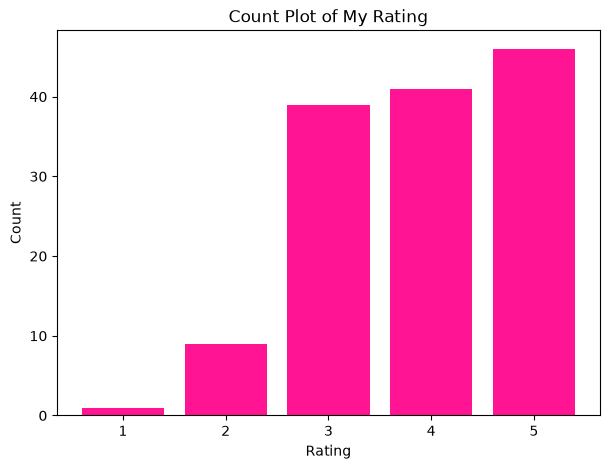

In [27]:
rating_distribution = read_books['My Rating'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(rating_distribution.index, rating_distribution, color='deeppink')
plt.title('Count Plot of My Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

The rating distribution is clearly left skewed. I tend to give ratings between 3 and 5.

#### Ratings over time

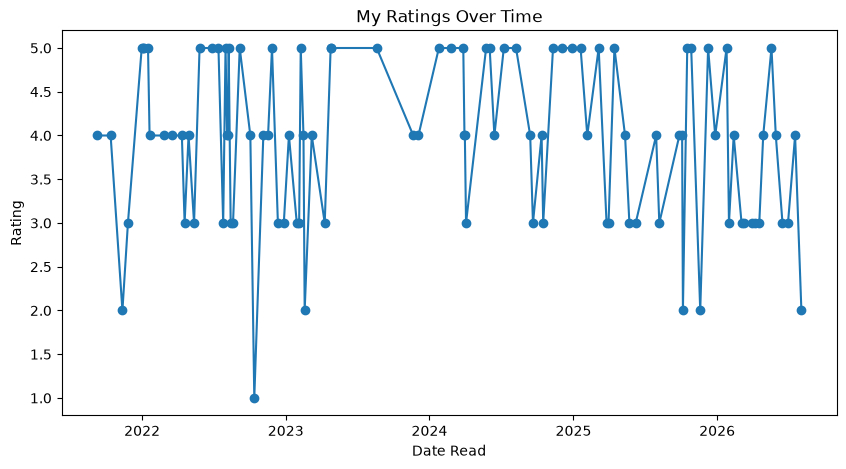

In [28]:
plot_data = read_books.dropna(subset=["Date Read"]).sort_values("Date Read")

plt.figure(figsize=(10, 5))
plt.plot(plot_data["Date Read"], plot_data["My Rating"], marker="o")
plt.title("My Ratings Over Time")
plt.xlabel("Date Read")
plt.ylabel("Rating")
plt.show()

#### Pages vs rating

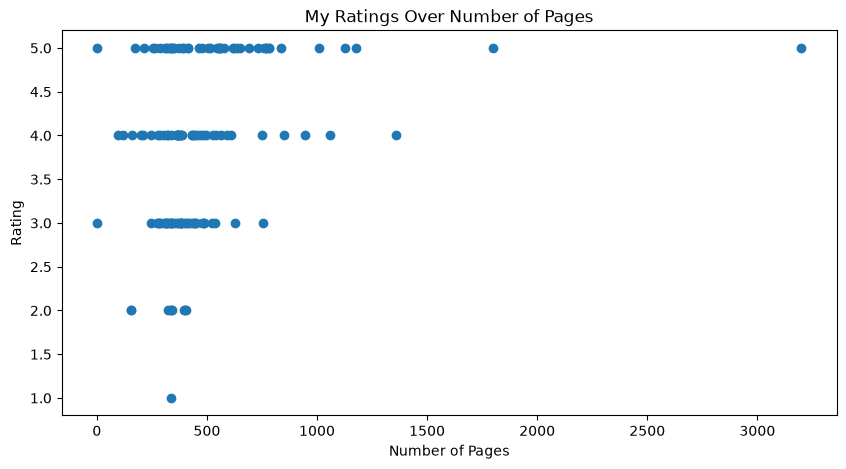

In [29]:
ratings = read_books["My Rating"]
pages = read_books["Number of Pages"]

plt.figure(figsize=(10, 5))
plt.scatter(pages, ratings)
plt.title("My Ratings Over Number of Pages")
plt.xlabel("Number of Pages")
plt.ylabel("Rating")
plt.show()